# CNN for Sentiment Analysis — NLTK Movie Reviews

A 1-D CNN slides filters over word embeddings to detect local phrases (e.g. "highly recommend", "waste of time") independent of position.

**Dataset**: NLTK `movie_reviews` — 2 000 labelled reviews (1 000 pos / 1 000 neg).

**Architecture**: Embedding → Conv1d (kernel sizes 3,4,5) → Global Max Pool → Dropout → Linear → Sigmoid

**(SOLUTION)**

## Step 1: Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import nltk
import random
from collections import Counter
import matplotlib.pyplot as plt

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', device)

device: mps


## Key Concept: Devices and `.to(device)`

PyTorch can run computations on the **CPU** or a **GPU** (NVIDIA CUDA or
Apple Silicon MPS). Moving a tensor or model to a device means its data and
computations live there.

```python
device = torch.device('mps' if torch.backends.mps.is_available()
                       else 'cuda' if torch.cuda.is_available()
                       else 'cpu')

model = MyModel().to(device)   # moves all weight tensors to device
X = X.to(device)               # moves input data to the same device
```

**Rule:** model and data must be on the *same* device — mixing them raises
a `RuntimeError`. Call `.to(device)` on both.

> 📖 [PyTorch — CUDA semantics](https://pytorch.org/docs/stable/notes/cuda.html)


## Key Concept: `Dataset` and `DataLoader`

`DataLoader` handles batching, shuffling, and parallel data loading so your
training loop stays simple.

```python
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X_train, y_train)   # pairs inputs with labels
loader  = DataLoader(dataset,
                     batch_size=64,
                     shuffle=True)           # reshuffles every epoch

for Xb, yb in loader:                       # Xb: (64, ...) one mini-batch
    ...
```

Key parameters:
- `batch_size` — number of samples per gradient update
- `shuffle=True` — randomise order each epoch (always use for training)
- `num_workers` — background processes for loading (set to 2-4 on most machines)

> 📖 [PyTorch — Writing a Custom Dataset](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html)


## Step 2: Load the Movie Reviews Corpus

In [2]:
from nltk.corpus import movie_reviews

random.seed(42)
docs = [(movie_reviews.words(fid), cat)
        for cat in movie_reviews.categories()
        for fid in movie_reviews.fileids(cat)]
random.shuffle(docs)

print(f'Total reviews : {len(docs)}')
print(f'Categories    : {movie_reviews.categories()}')
print(f'Sample words  : {list(docs[0][0])[:10]}')
print(f'Label         : {docs[0][1]}')

Total reviews : 2000
Categories    : ['neg', 'pos']
Sample words  : ['mr', '.', 'bean', ',', 'a', 'bumbling', 'security', 'guard', 'from', 'england']
Label         : neg


## Key Concept: Word Embeddings

Raw text cannot be fed directly into a neural network — we need numeric
representations.

**One-hot encoding** (naïve): word `i` → a sparse `(vocab_size,)` vector
with a single 1 at position `i`. Problems: enormous dimensionality (10 000+),
no notion of similarity ("film" and "movie" are orthogonal), sparse gradients.

**Learned embeddings** (`nn.Embedding`): a trainable lookup table of shape
`(vocab_size, embed_dim)`. Each word maps to a dense `embed_dim`-dimensional
vector. Trained end-to-end, embeddings organise themselves so semantically
similar words cluster together in embedding space.

```python
nn.Embedding(vocab_size, embed_dim, padding_idx=0)
# (batch_size, seq_len)  →  (batch_size, seq_len, embed_dim)
```

`padding_idx=0`: the `<PAD>` token's embedding is permanently zeroed out so
padding never contributes to the model's signal.

**Why not pre-trained embeddings (GloVe, Word2Vec)?**
They'd likely improve accuracy here. We train from scratch so the mechanism
is transparent and the notebook is self-contained.


## Step 3: Build a Vocabulary

In [3]:
MAX_VOCAB = 10000  # cap vocabulary; tail words are rare and add noise
MAX_LEN   = 200    # truncate/pad all reviews to this length → fixed-size input tensor

all_words = [w.lower() for ws, _ in docs for w in ws]
freq      = Counter(all_words)
# Index 0 = <PAD>: embedding's padding_idx=0 zeroes this vector out (no signal)
# Index 1 = <UNK>: any word outside the top 9998 maps here
vocab = {'<PAD>': 0, '<UNK>': 1}
for w, _ in freq.most_common(MAX_VOCAB - 2):
    vocab[w] = len(vocab)

print(f'Vocab size: {len(vocab)}')
print(f'Top 10   : {freq.most_common(10)}')

Vocab size: 10000
Top 10   : [(',', 77717), ('the', 76529), ('.', 65876), ('a', 38106), ('and', 35576), ('of', 34123), ('to', 31937), ("'", 30585), ('is', 25195), ('in', 21822)]


## Step 4: Encode Reviews and Pad/Truncate

In [4]:
def encode(words, vocab, max_len):
    tokens = [vocab.get(w.lower(), 1) for w in words][:max_len]  # truncate at 200
    tokens += [0] * (max_len - len(tokens))  # pad shorter reviews with <PAD>=0
    return tokens  # list of exactly max_len integers

X_data = [encode(ws, vocab, MAX_LEN) for ws, _ in docs]
y_data = [1 if label == 'pos' else 0 for _, label in docs]

# X_tensor: (2000, 200) — 2000 reviews × 200 word indices; dtype=long for nn.Embedding
X_tensor = torch.tensor(X_data, dtype=torch.long)
# y_tensor: (2000,) — float32 scalar per review for BCELoss
y_tensor = torch.tensor(y_data, dtype=torch.float32)
print('X:', X_tensor.shape, '  y:', y_tensor.shape)

X: torch.Size([2000, 200])   y: torch.Size([2000])


## Step 5: Train / Test Split and DataLoaders

In [5]:
split = int(0.8 * len(X_tensor))         # 1600 train / 400 test
X_train, X_test = X_tensor[:split], X_tensor[split:]  # (1600,200) / (400,200)
y_train, y_test = y_tensor[:split], y_tensor[split:]  # (1600,)   / (400,)

# Each batch yields Xb (32, 200) word indices and yb (32,) labels
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=32)
print(f'Train batches: {len(train_loader)}  Test batches: {len(test_loader)}')

Train batches: 50  Test batches: 13


## Key Concept: 1D Convolutions for Text

A 1D convolution slides a kernel of width `k` across the sequence length
dimension, computing a dot product at every position. For text, this detects
**local n-gram patterns** anywhere in the review.

| Kernel size | What it detects |
|-------------|----------------|
| 3           | Trigrams — "not very good", "highly recommend" |
| 4           | 4-grams — "one of the best" |
| 5           | 5-grams — broader phrase patterns |

**Global max pooling** collapses the variable-length output to a single
scalar per filter: "does this pattern appear *anywhere* in the review?"
This makes the model **position-invariant** — "horrible" matters whether it
appears at the start or end.

**Shape flow through this model** (B = batch_size, the number of reviews per batch):
```
Input:           (B, 200)           word indices, one row per review
Embedding:       (B, 200, 64)       word vectors, 64 dims per word
Permute(0,2,1):  (B, 64, 200)       Conv1d expects (batch, channels, length)
Conv1d(k=3):     (B, 128, 198)      198 = 200 - 3 + 1 positions
Max pool:        (B, 128)           strongest trigram signal per filter
Concat 3 sizes:  (B, 384)           128 filters × 3 kernel sizes
Dropout + fc:    (B, 1)             sentiment probability
```

> 📖 [PyTorch — nn.Conv1d docs](https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html)

## Step 6: Define the CNN Model

In [6]:
class SentimentCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, num_filters=128, kernel_sizes=(3,4,5)):
        super().__init__()
        # Embedding: lookup table shape (vocab_size, 64)
        # maps each integer index → a 64-d learned vector: (B,200) → (B,200,64)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # Conv1d(in_channels, out_channels, kernel_size)
        #   in_channels = embed_dim (64) — one channel per embedding dimension
        #   kernel_sizes 3,4,5 detect trigrams, 4-grams, 5-grams
        self.convs      = nn.ModuleList(
            [nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes]
        )
        self.dropout = nn.Dropout(0.5)  # applied to the 384-d concatenated vector
        # 128 filters × 3 kernel sizes = 384 total features → 1 output logit
        self.fc      = nn.Linear(num_filters * len(kernel_sizes), 1)

    def forward(self, x):                              # x: (B, 200) word indices
        x = self.embedding(x)                          # → (B, 200, 64) word vectors
        x = x.permute(0, 2, 1)                         # → (B, 64, 200) Conv1d needs (B,C,L)
        # Conv1d kernel k: (B,64,200) → (B,128,200-k+1)
        # .max(dim=-1).values: global max pool over length → (B, 128)
        pooled = [F.relu(conv(x)).max(dim=-1).values for conv in self.convs]
        cat = self.dropout(torch.cat(pooled, dim=1))   # cat 3×(B,128) → (B,384)
        return torch.sigmoid(self.fc(cat))              # (B,384) → (B,1) probability

vocab_size = len(vocab)
model = SentimentCNN(vocab_size).to(device)
print(model)

SentimentCNN(
  (embedding): Embedding(10000, 64, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,))
    (1): Conv1d(64, 128, kernel_size=(4,), stride=(1,))
    (2): Conv1d(64, 128, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=384, out_features=1, bias=True)
)


### Concept Check: CNN Architecture — Answers

**Q1.** The embedding output is `(batch_size, 200, 64)` but `nn.Conv1d` expects
`(batch_size, in_channels, length)`. What does `.permute(0, 2, 1)` produce, and why
is this reshape required?

**→** `.permute(0, 2, 1)` swaps dimensions 1 and 2:
`(batch_size, 200, 64)` → `(batch_size, 64, 200)`.
`nn.Conv1d(in_channels=64, ...)` treats the middle dimension as channels and
the last as the sequence it slides over — exactly `(batch_size, 64, 200)`.

**Q2.** Three separate convolutions (kernel sizes 3, 4, 5) are used in
parallel and their outputs concatenated. Why not just use one kernel size?
What would be lost?

**→** A single kernel size only detects patterns of one specific length.
Combining 3, 4, and 5 lets the model detect short phrases ("great"), medium
phrases ("not that good"), and longer expressions simultaneously. Removing
multi-scale detection typically hurts accuracy by 2-5%.

**Q3.** Global max pooling discards positional information entirely.
For sentiment analysis this is fine — but name a task where position
matters and max pooling would hurt performance.

**→** Tasks where position matters:
- **Named entity recognition** (BIO tagging) — the label depends on where a word is
- **Question answering** — "the answer *follows* the question"
- **Machine translation** — word order differs between languages
Max pooling + position-invariance is a good inductive bias *only* for tasks
where the presence of a pattern (not its location) is the signal.

## Step 7: Train the Model

In [7]:
criterion  = nn.BCELoss()
optimizer  = optim.Adam(model.parameters(), lr=0.001)
train_losses = []

for epoch in range(10):
    model.train()
    total_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)  # Xb: (32,200)  yb: (32,)

        # Forward: embedding → conv → pool → linear → sigmoid. Graph is recorded.
        out  = model(Xb).squeeze()  # (32,1) → (32,) to match yb's shape for BCELoss

        loss = criterion(out, yb)   # BCELoss: per-sample binary cross-entropy, then mean

        optimizer.zero_grad()       # clear last batch's gradients — PyTorch accumulates
        loss.backward()             # backprop through conv layers, embeddings, everything
        optimizer.step()            # Adam updates each weight with its own adaptive lr

        total_loss += loss.item()   # detach from graph; just a Python float now
    avg = total_loss / len(train_loader)
    train_losses.append(avg)
    print(f'Epoch {epoch+1:2d} | Loss: {avg:.4f}')


Epoch  1 | Loss: 0.8093


Epoch  2 | Loss: 0.6876


Epoch  3 | Loss: 0.6390


Epoch  4 | Loss: 0.5738


Epoch  5 | Loss: 0.5551


Epoch  6 | Loss: 0.4967


Epoch  7 | Loss: 0.4711


Epoch  8 | Loss: 0.4246


Epoch  9 | Loss: 0.4141


Epoch 10 | Loss: 0.3716


## Step 8: Evaluate on Test Set

In [8]:
model.eval()
correct = total = 0
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        preds = torch.round(model(Xb).squeeze())  # (32,1)→(32,), threshold at 0.5
        correct += (preds == yb).sum().item()       # count matches in this batch
        total   += yb.size(0)                       # accumulate total samples
print(f'Test accuracy: {correct/total*100:.1f}%')

Test accuracy: 54.5%


### Concept Check: Regularisation & Evaluation — Answers

**Q1.** `nn.Dropout(0.5)` zeros 50% of activations randomly during training.
How does this prevent overfitting? Why is it *disabled* during `model.eval()`?

**→** Dropout acts as an ensemble: each training step uses a different
random sub-network, forcing redundant representations. No single neuron can
become indispensable, making features more broadly useful.
At eval time, all neurons are active and their outputs are *scaled* implicitly
(the expected output matches training thanks to the 1/(1-p) scaling factor
PyTorch uses internally).

**Q2.** If train accuracy is 95% but test accuracy is 65%, what is happening
and what are three techniques you could use to close the gap?

**→** This is **overfitting** — the model has memorised training specifics.
Three remedies: (a) increase dropout rate, (b) reduce model capacity
(fewer filters), (c) add L2 weight decay (`weight_decay=` in the optimiser),
(d) train on more data / data augmentation.

**Q3.** The model uses `nn.BCELoss` with a sigmoid output.
`nn.BCEWithLogitsLoss` (raw logit, no sigmoid) is numerically more stable.
Why? When would numerical stability matter in practice?

**→** `sigmoid(x)` for large `|x|` suffers floating-point saturation:
`sigmoid(100) = 1.0` and `log(1.0 - 1.0) = log(0) = -inf`.
`BCEWithLogitsLoss` computes `log(1 + exp(-x))` using the numerically stable
log-sum-exp trick, avoiding this. It matters when logits grow large late in
training, which is common without careful initialisation.

## Step 9: Predict on a New Review

In [9]:
def predict(text, model, vocab, max_len, device):
    model.eval()
    with torch.no_grad():
        tokens = [vocab.get(w.lower(), 1) for w in text.split()][:max_len]
        tokens += [0] * (max_len - len(tokens))
        x = torch.tensor([tokens], dtype=torch.long, device=device)
        prob = model(x).item()
        return f'positive ({prob:.2f})' if prob >= 0.5 else f'negative ({prob:.2f})'

print(predict('This film was absolutely wonderful and moving', model, vocab, MAX_LEN, device))
print(predict('Terrible waste of time, boring and predictable', model, vocab, MAX_LEN, device))

positive (0.53)
negative (0.36)


## Step 10: Visualize the CNN Architecture

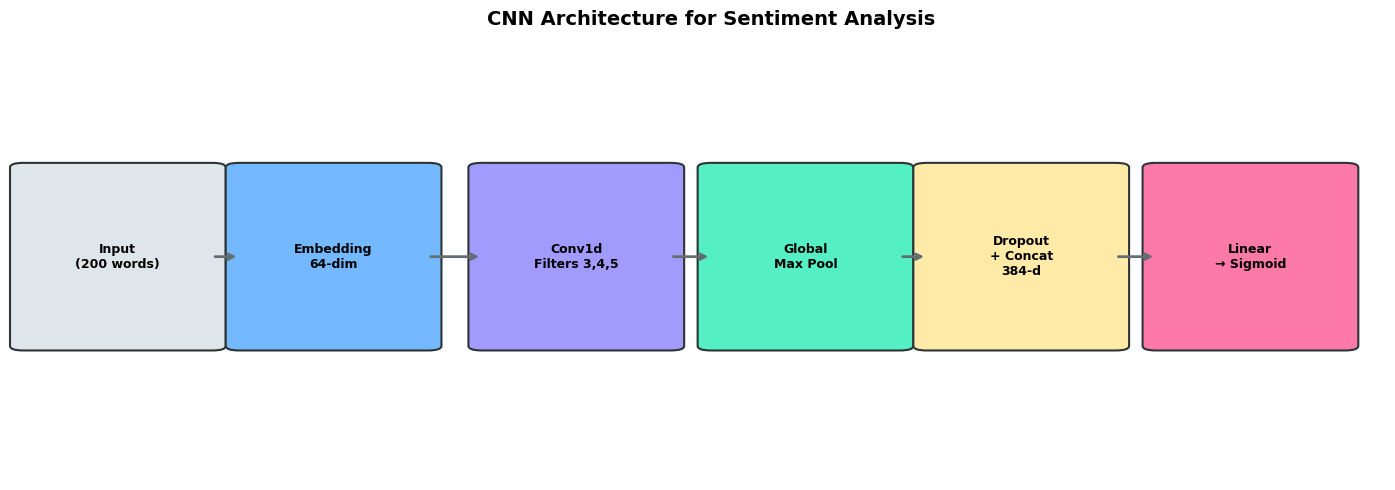

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')
ax.set_title('CNN Architecture for Sentiment Analysis', fontsize=14, fontweight='bold')

components = [
    (0.06,  'Input\n(200 words)',       '#dfe6e9'),
    (0.22,  'Embedding\n64-dim',         '#74b9ff'),
    (0.40,  'Conv1d\nFilters 3,4,5',    '#a29bfe'),
    (0.57,  'Global\nMax Pool',          '#55efc4'),
    (0.73,  'Dropout\n+ Concat\n384-d', '#ffeaa7'),
    (0.90,  'Linear\n→ Sigmoid',         '#fd79a8'),
]
for x, label, color in components:
    rect = mpatches.FancyBboxPatch(
        (x - 0.07, 0.3), 0.14, 0.4,
        boxstyle='round,pad=0.01',
        facecolor=color, edgecolor='#2d3436', linewidth=1.5,
        transform=ax.transAxes, clip_on=False
    )
    ax.add_patch(rect)
    ax.text(x, 0.5, label, ha='center', va='center', fontsize=9,
            transform=ax.transAxes, fontweight='bold')

for i in range(len(components) - 1):
    x0 = components[i][0] + 0.07
    x1 = components[i + 1][0] - 0.07
    ax.annotate('', xy=(x1, 0.5), xytext=(x0, 0.5),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='#636e72', lw=2))
plt.tight_layout()
plt.show()


## Step 11: Plot Training Loss

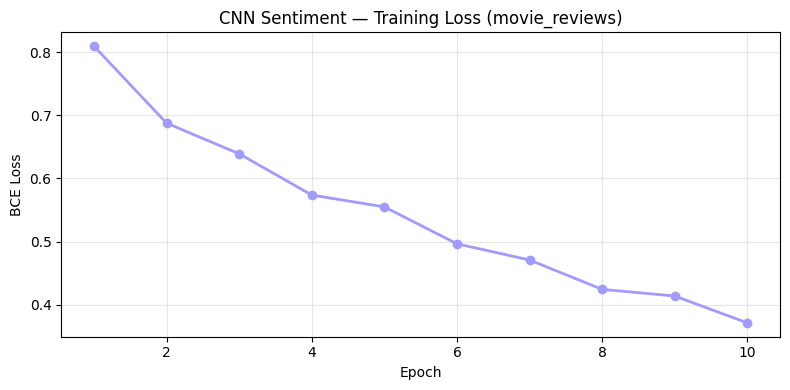

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, 'o-', color='#a29bfe', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('CNN Sentiment — Training Loss (movie_reviews)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()